# Cluster analysis

To characterize the spatial organization of the system, clusters are identified independently for round and elongated cells. Two cells are considered connected when they belong to the same phenotype and interact significantly according to the same overlap criterion used in the dynamics. Connectivity is transitive, and clusters are reconstructed independently for each saved configuration. Isolated cells are therefore retained as clusters of size one.

For each phenotype $\alpha\in\{R,E\}$, we denote by $N_\alpha$ the number of cells belonging to that phenotype and by $S_{1,\alpha}$ and $S_{2,\alpha}$ the sizes of the largest and second-largest clusters, respectively.

The size of the largest cluster can be normalized either by the total number of cells,

$$
\frac{S_{1,\alpha}}{N},
$$

or by the number of cells belonging to the corresponding phenotype,

$$
\frac{S_{1,\alpha}}{N_\alpha}.
$$

These quantities provide complementary information. The first measures the fraction of the entire system contained in the largest cluster of phenotype $\alpha$, whereas the second measures how strongly the population of that phenotype is organized into a single connected structure.

They are related through

$$
\frac{S_{1,\alpha}}{N}
=
\frac{N_\alpha}{N}
\frac{S_{1,\alpha}}{N_\alpha}.
$$

Thus, changes in the macroscopic size of a cluster may arise either from changes in the abundance of a phenotype or from changes in its internal spatial organization.

To quantify the relative dominance of the largest cluster over the second-largest one, we define

$$
\psi_\alpha
=
\frac{S_{1,\alpha}-S_{2,\alpha}}
{S_{1,\alpha}+S_{2,\alpha}}.
$$

Values of $\psi_\alpha$ close to one indicate a strongly dominant largest cluster, whereas smaller values indicate that the two largest structures have comparable sizes.

In addition to the largest clusters, we analyze the fragmentation of each population through the number of clusters, the fraction of isolated cells, and the distribution of finite-cluster sizes. For elongated clusters, their internal polar and nematic order are also available, together with observables describing the collective motion of each cluster.

The aim of this analysis is to determine how the spatial organization of the round and elongated populations changes across the morphological transition previously identified from the elongated fraction $f_E$.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data
We start by loading and inspecting the processed order-parameter data.

In [2]:
DATA_DIR = "data/clusters"

time_series = pd.read_parquet(
    f"{DATA_DIR}/cluster_time_series.parquet"
)

snapshots = pd.read_parquet(
    f"{DATA_DIR}/cluster_snapshots.parquet"
)

size_counts = pd.read_parquet(
    f"{DATA_DIR}/cluster_size_counts.parquet"
)

raw = pd.read_parquet(
    f"{DATA_DIR}/cluster_raw.parquet"
)

In [3]:
print("N values:")
print(sorted(snapshots["N"].unique()))

print("\nrho values by N:")
for N, group in snapshots.groupby("N"):
    print(N, sorted(group["rho"].unique()))

print("\nNumber of seeds by N and rho:")
display(
    snapshots.groupby(["N", "rho"])["seed"]
    .nunique()
    .unstack()
)

N values:
[np.int64(10000)]

rho values by N:
10000 [np.float64(0.8), np.float64(0.81), np.float64(0.82), np.float64(0.83), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.87)]

Number of seeds by N and rho:


rho,0.80,0.81,0.82,0.83,0.84,0.85,0.86,0.87
N,,,,,,,,
10000,32,32,32,32,32,32,32,32


In [4]:
print("Phenotypes:")
print(time_series["phenotype"].unique())

print("\nTime series steps:")
print("min =", time_series["step"].min())
print("max =", time_series["step"].max())
print("number of unique steps =", time_series["step"].nunique())

print("\nSnapshots steps:")
print("min =", snapshots["step"].min())
print("max =", snapshots["step"].max())
print("number of unique steps =", snapshots["step"].nunique())

print("\nFirst time-series steps:")
print(sorted(time_series["step"].unique())[:20])

print("\nFirst snapshot steps:")
print(sorted(snapshots["step"].unique())[:20])

Phenotypes:
<ArrowStringArray>
['elongated', 'round']
Length: 2, dtype: str

Time series steps:
min = 0
max = 50000
number of unique steps = 501

Snapshots steps:
min = 0
max = 50000
number of unique steps = 51

First time-series steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]

First snapshot steps:
[np.int64(0), np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000), np.int64(11000), np.int64(12000), np.int64(13000), np.int64(14000), np.int64(15000), np.int64(16000), np.int64(17000), np.int64(18000), np.int64(19000)]


In [5]:
display(
    time_series
    .groupby(["rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
    .groupby("rho")
    .agg(["min", "max"])
)

min        max        nunique     
     min max    min    max     min  max
rho                                    
0.80   0   0  50000  50000     501  501
0.81   0   0  50000  50000     501  501
0.82   0   0  50000  50000     501  501
0.83   0   0  50000  50000     501  501
0.84   0   0  50000  50000     501  501
0.85   0   0  50000  50000     501  501
0.86   0   0  50000  50000     501  501
0.87   0   0  50000  50000     501  501

## Time evolution of cluster structure

We first study how the cluster structure develops from the initially round configuration.

For each phenotype, the fraction of the total system contained in its largest cluster can be written as

$$
\frac{S_{1,\alpha}}{N}
=
\frac{N_\alpha}{N}
\frac{S_{1,\alpha}}{N_\alpha}.
$$

This decomposition allows us to distinguish two contributions to the growth or disappearance of a macroscopic cluster: changes in the abundance of the corresponding phenotype, $N_\alpha/N$, and changes in the connectivity of that population, measured by $S_{1,\alpha}/N_\alpha$.

We therefore examine the time evolution of these quantities separately for round and elongated cells.

In [14]:
# Average over seeds at each time
# We group by density, step, and phenotype,
# and then compute the mean of the fraction of phenotype and the mean of S1/N and S1/Nphenotype.
cluster_time = (
    time_series
    .groupby(["rho", "step", "phenotype"])
    .agg(
        fraction_phenotype_mean=("fraction_phenotype", "mean"),
        S1_over_N_mean=("S1_over_N", "mean"),
        S1_over_Nphenotype_mean=("S1_over_Nphenotype", "mean"),
    )
    .reset_index()
)

cluster_time.head()

,rho,step,phenotype,fraction_phenotype_mean,S1_over_N_mean,S1_over_Nphenotype_mean
0,0.8,0,elongated,0.000000,0.000000,NaN
1,0.8,0,round,1.000000,0.007010,0.007010
2,0.8,100,elongated,0.003663,0.000240,0.067752
3,0.8,100,round,0.996337,0.008042,0.008071
4,0.8,200,elongated,0.005865,0.000347,0.060160


We start plotting $\frac{S_{1,\alpha}}{N}$:

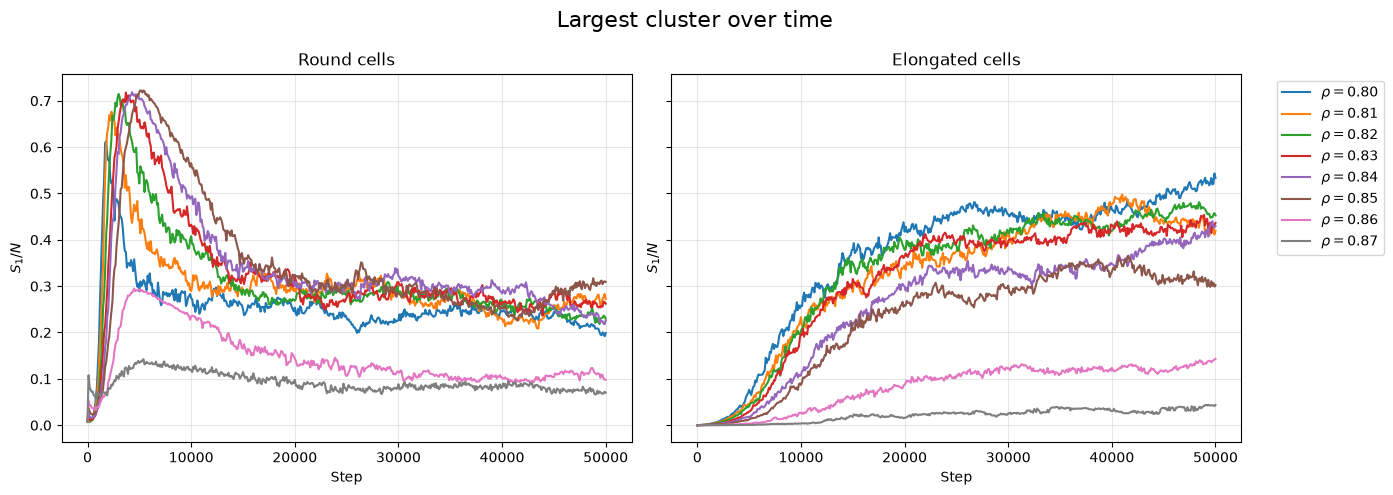

In [15]:
# Plot the largest cluster over time for each phenotype and density
fig, axs = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
    sharey=True,
)

phenotypes = ["round", "elongated"]

titles = {
    "round": "Round cells",
    "elongated": "Elongated cells",
}

# For each phenotype, plot the largest cluster over time for each density
for ax, phenotype in zip(axs, phenotypes):

    df_pheno = cluster_time[
        cluster_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho["S1_over_N_mean"],
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_title(titles[phenotype])
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$S_1/N$")
    ax.grid(alpha=0.3)

axs[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

graph_title = "Largest cluster over time"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

For elongated cells, the fraction of the total system contained in the largest cluster decreases at the highest densities. This behavior is expected to be closely related to the suppression of the elongated population observed previously through $f_E$.

The behavior of round cells is qualitatively different. Although $S_{1,R}/N$ initially increases with density (compare $\rho=0.80$ and $\rho=0.85$), it decreases again for the highest densities, particularly around $\rho=0.86$ and $\rho=0.87$. This is not simply explained by the phenotypic composition, since these densities correspond to systems dominated by round cells.

This suggests that a high fraction of round cells does not necessarily imply that they form a single macroscopic connected structure. In particular, the suppression of elongation at high density may result from geometric constraints even in the absence of a dominant interacting cluster of round cells.

To separate changes in phenotypic abundance from changes in connectivity, we now examine $N_\alpha/N$ and $S_{1,\alpha}/N_\alpha$ independently.

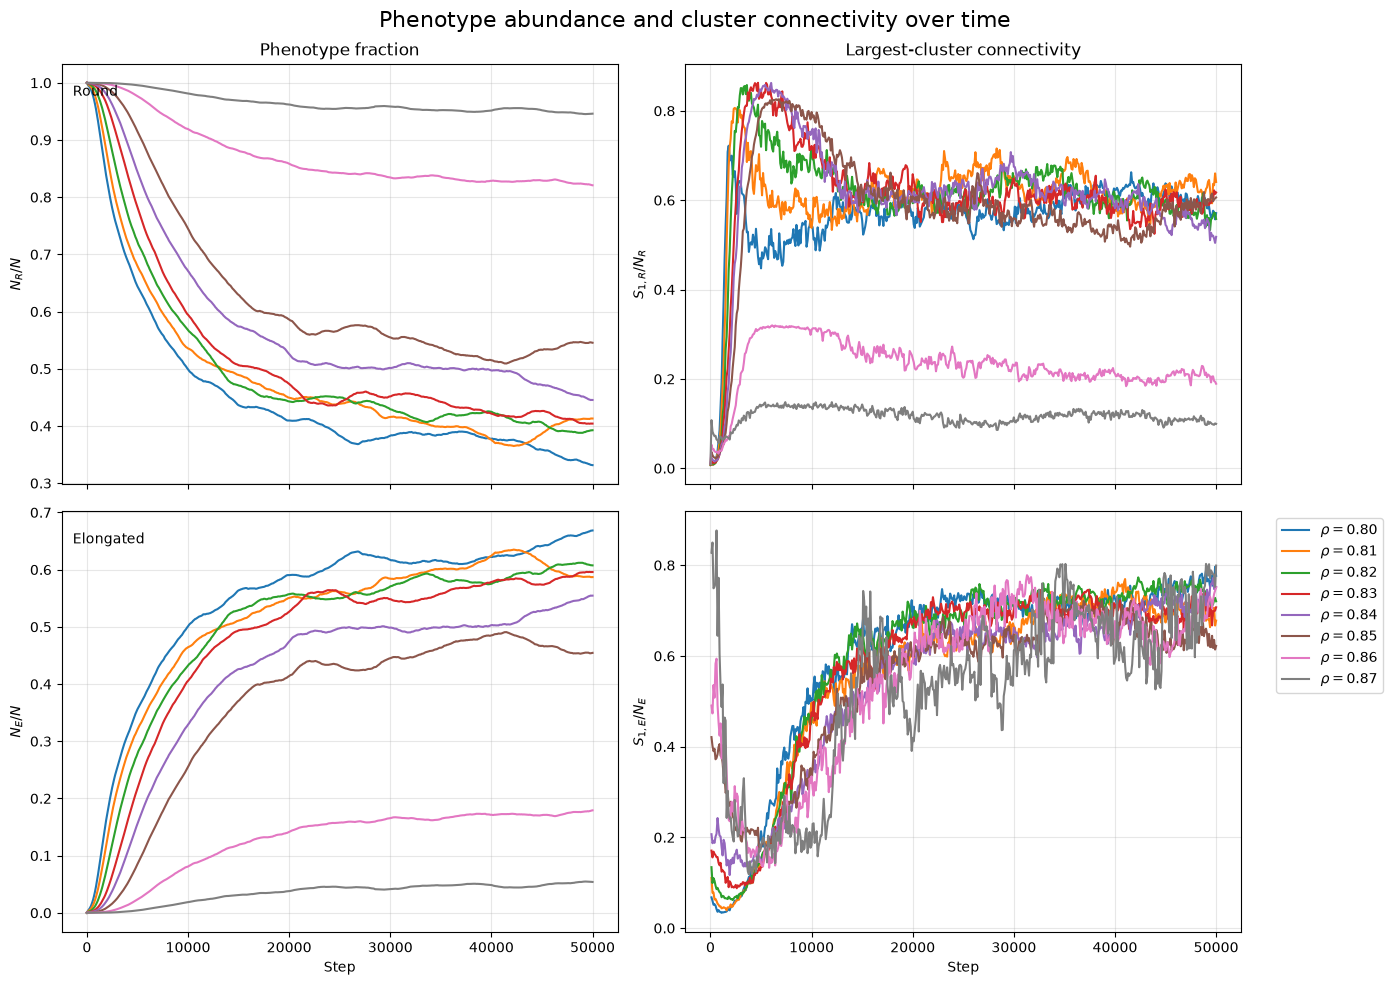

In [8]:
# Plot the fraction of each phenotype and the fraction of the 
# phenotype in its largest cluster over time for each density
fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    sharex=True,
)

phenotypes = ["round", "elongated"]

# For each phenotype, plot the fraction of each phenotype and the fraction of the
# phenotype in its largest cluster over time for each density
for row, phenotype in enumerate(phenotypes):

    df_pheno = cluster_time[
        cluster_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        # Fraction of cells of the phenotype
        axs[row, 0].plot(
            df_rho["step"],
            df_rho["fraction_phenotype_mean"],
            label=fr"$\rho={rho:.2f}$",
        )

        # Fraction of the phenotype in its largest cluster
        axs[row, 1].plot(
            df_rho["step"],
            df_rho["S1_over_Nphenotype_mean"],
            label=fr"$\rho={rho:.2f}$",
        )


axs[0, 0].set_title("Phenotype fraction")
axs[0, 1].set_title("Largest-cluster connectivity")

axs[0, 0].set_ylabel(r"$N_R/N$")
axs[0, 1].set_ylabel(r"$S_{1,R}/N_R$")

axs[1, 0].set_ylabel(r"$N_E/N$")
axs[1, 1].set_ylabel(r"$S_{1,E}/N_E$")

for ax in axs[1, :]:
    ax.set_xlabel("Step")

for ax in axs.flat:
    ax.grid(alpha=0.3)

# Add text labels to the subplots
axs[0, 0].text(
    0.02,
    0.95,
    "Round",
    transform=axs[0, 0].transAxes,
    va="top",
)

# Add text labels to the subplots
axs[1, 0].text(
    0.02,
    0.95,
    "Elongated",
    transform=axs[1, 0].transAxes,
    va="top",
)

# Add legends to the subplots
axs[1, 1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

graph_title = "Phenotype abundance and cluster connectivity over time"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The decomposition shows that phenotypic abundance and cluster connectivity behave quite differently.

For round cells, $N_R/N$ increases strongly with density, but at the highest densities $S_{1,R}/N_R$ decreases. So even though most cells are round, they do not form a large interacting cluster according to our current definition.

My guess is that elongation is still blocked by crowding and spatial constraints, even without a giant interaction-based cluster. If we used a more geometric cluster definition, for example connecting cells within a distance $R$, we might actually recover a giant cluster in this regime.

For elongated cells, most of the density dependence comes from $N_E/N$. When a substantial elongated population exists, a large fraction of it usually belongs to the largest elongated cluster.

So the decrease of $S_{1,E}/N$ at high density seems to be mainly due to the disappearance of elongated cells, rather than to strong fragmentation of the elongated population.

At very early times, and also at the highest densities, $S_{1,E}/N_E$ should be interpreted carefully because $N_E$ is very small.

# Steady state cluster structure

### Largest cluster size

To compare the cluster structure between densities, we average the cluster observables over the final $10\%$ of each realization. As in the order-parameter analysis, this window is used to obtain more stable late-time estimates without assuming that every realization has reached a fully stationary state.

We first average over time independently for each seed, and then average over realizations.

In [9]:
# Take the last 10% of the simulation steps as the steady-state window
steady_fraction = 0.10

max_step = snapshots["step"].max()
steady_start = max_step * (1 - steady_fraction)

cluster_late = snapshots[
    snapshots["step"] >= steady_start
].copy()

print("Late-time window starts at step:", steady_start)

Late-time window starts at step: 45000.0


In [10]:
# Compute the mean of the fraction of phenotype and the mean of S1/N and S1/Nphenotype
# over the late-time window for each seed, density, and phenotype
cluster_seed_stats = (
    cluster_late
    .groupby(["N", "rho", "seed", "phenotype"])
    .agg(
        fraction_phenotype=("fraction_phenotype", "mean"),

        S1_over_N=("S1_over_N", "mean"),
        S1_over_Nphenotype=("S1_over_Nphenotype", "mean"),

        S2_over_N=("S2_over_N", "mean"),
        S2_over_Nphenotype=("S2_over_Nphenotype", "mean"),

        psi=("psi", "mean"),
    )
    .reset_index()
)

cluster_seed_stats.head()

,N,rho,seed,phenotype,fraction_phenotype,S1_over_N,S1_over_Nphenotype,S2_over_N,S2_over_Nphenotype,psi
0,10000,0.8,12944511869278,elongated,0.743019,0.629500,0.846587,0.014389,0.019288,0.955374
1,10000,0.8,12944511869278,round,0.256981,0.190630,0.751821,0.018204,0.067117,0.828609
2,10000,0.8,78804909138230,elongated,0.688426,0.461648,0.662880,0.135185,0.203876,0.523148
3,10000,0.8,78804909138230,round,0.311574,0.211981,0.681126,0.054889,0.173362,0.592335
4,10000,0.8,170902461924754,elongated,0.678574,0.608426,0.894243,0.010500,0.015926,0.964296


In [11]:
# Compute the mean of the fraction of phenotype and the mean of S1/N and S1/Nphenotype
cluster_rho_stats = (
    cluster_seed_stats
    .groupby(["N", "rho", "phenotype"])
    .agg(
        fraction_phenotype=("fraction_phenotype", "mean"),

        S1_over_N=("S1_over_N", "mean"),
        S1_over_Nphenotype=("S1_over_Nphenotype", "mean"),

        S2_over_N=("S2_over_N", "mean"),
        S2_over_Nphenotype=("S2_over_Nphenotype", "mean"),

        psi=("psi", "mean"),
    )
    .reset_index()
)

cluster_rho_stats

,N,rho,phenotype,fraction_phenotype,S1_over_N,S1_over_Nphenotype,S2_over_N,S2_over_Nphenotype,psi
0,10000,0.80,elongated,0.655733,0.514276,0.761402,0.040934,0.069151,0.820270
1,10000,0.80,round,0.344267,0.221442,0.606526,0.051566,0.153186,0.552241
2,10000,0.81,elongated,0.594998,0.431009,0.691911,0.048427,0.090837,0.748683
3,10000,0.81,round,0.405002,0.270553,0.639207,0.065343,0.166380,0.558356
4,10000,0.82,elongated,0.606094,0.463368,0.740592,0.032548,0.060941,0.825206
5,10000,0.82,round,0.393906,0.234421,0.568398,0.074250,0.189184,0.474287
6,10000,0.83,elongated,0.586616,0.425814,0.696248,0.050177,0.093271,0.743794
7,10000,0.83,round,0.413384,0.272479,0.604908,0.073874,0.183429,0.507778
8,10000,0.84,elongated,0.540761,0.408505,0.731849,0.032910,0.066853,0.818524
9,10000,0.84,round,0.459239,0.240292,0.542488,0.076605,0.186089,0.440131


We first consider the fraction of the whole system contained in the largest cluster of each phenotype,

$$
\frac{S_{1,\alpha}}{N}.
$$

This gives a direct measure of the macroscopic importance of the largest round and elongated structures as density is varied.

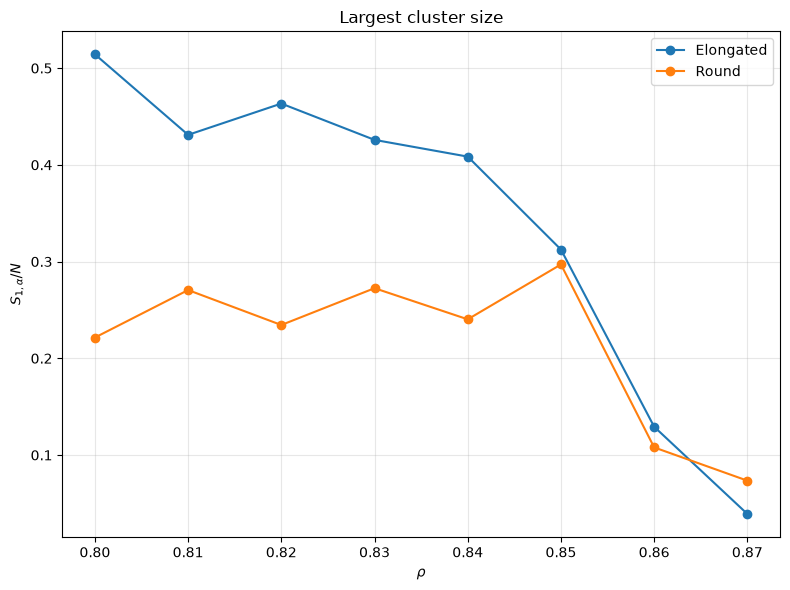

In [12]:
# Plot the largest cluster size as a function of density for each phenotype
plt.figure(figsize=(8, 6))

for phenotype, df_pheno in cluster_rho_stats.groupby("phenotype"):

    plt.plot(
        df_pheno["rho"],
        df_pheno["S1_over_N"],
        marker="o",
        label=phenotype.capitalize(),
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$S_{1,\alpha}/N$")

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Largest cluster size"

plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Largest-cluster dominance

The size of the largest cluster does not tell us whether it is clearly dominant over the remaining structures. We therefore also consider

$$
\psi_\alpha
=
\frac{S_{1,\alpha}-S_{2,\alpha}}
{S_{1,\alpha}+S_{2,\alpha}}.
$$

A value close to one corresponds to a clearly dominant largest cluster, while smaller values indicate that the two largest clusters have more comparable sizes.

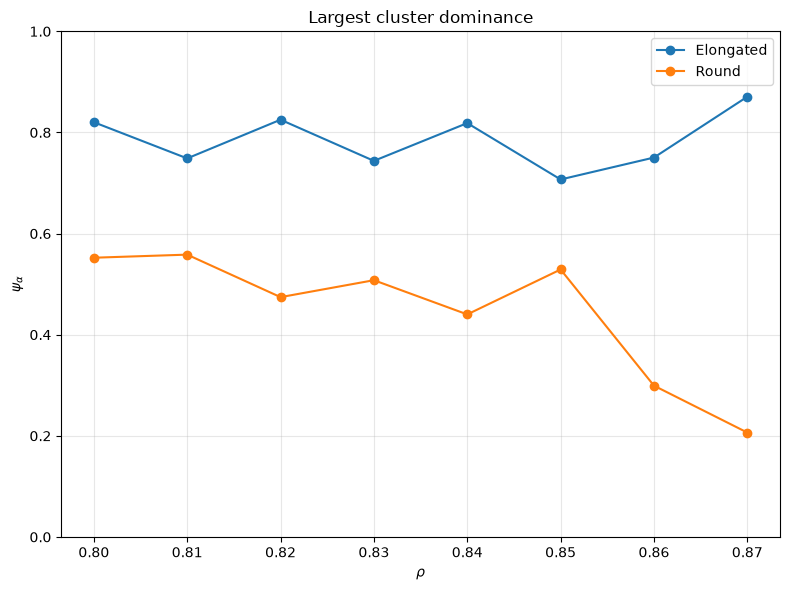

In [13]:
plt.figure(figsize=(8, 6))

for phenotype, df_pheno in cluster_rho_stats.groupby("phenotype"):

    plt.plot(
        df_pheno["rho"],
        df_pheno["psi"],
        marker="o",
        label=phenotype.capitalize(),
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$\psi_\alpha$")
plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Largest cluster dominance"
plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

For elongated cells, $\psi_E$ remains relatively large over the whole density range, suggesting that the largest elongated cluster is usually clearly dominant over the second-largest one.

For round cells, $\psi_R$ decreases strongly at $\rho=0.86$ and $\rho=0.87$. Together with the decrease of $S_{1,R}/N_R$, this suggests that the round population becomes less dominated by a single connected structure at high density.

However, $\psi_R$ alone does not tell us whether this corresponds to a few comparable clusters or to fragmentation into many smaller clusters. To check this, we next look at the number of clusters.